In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

In [ ]:
data = pd.read_csv("/content/DOGE-USD.csv")
data

,Date,Open,High,Low,Close,Adj Close,Volume
0,2017-11-09,0.001207,0.001415,0.001181,0.001415,0.001415,6259550.0
1,2017-11-10,0.001421,0.001431,0.001125,0.001163,0.001163,4246520.0
2,2017-11-11,0.001146,0.001257,0.001141,0.001201,0.001201,2231080.0
3,2017-11-12,0.001189,0.001210,0.001002,0.001038,0.001038,3288960.0
4,2017-11-13,0.001046,0.001212,0.001019,0.001211,0.001211,2481270.0
...,...,...,...,...,...,...,...
1756,2022-08-31,0.061534,0.063333,0.061058,0.061330,0.061330,309748693.0
1757,2022-09-01,0.061336,0.062479,0.060194,0.062372,0.062372,328765413.0
1758,2022-09-02,0.062372,0.062712,0.060947,0.061635,0.061635,273453013.0
1759,2022-09-03,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# checking the correlation
correlation_matrix=data.corr(numeric_only=True)
correlation_matrix

,Open,High,Low,Close,Adj Close,Volume
Open,1.000000,0.993904,0.993707,0.992514,0.992514,0.554850
High,0.993904,1.000000,0.986497,0.995104,0.995104,0.619321
Low,0.993707,0.986497,1.000000,0.994575,0.994575,0.519991
Close,0.992514,0.995104,0.994575,1.000000,1.000000,0.588678
Adj Close,0.992514,0.995104,0.994575,1.000000,1.000000,0.588678
Volume,0.554850,0.619321,0.519991,0.588678,0.588678,1.000000


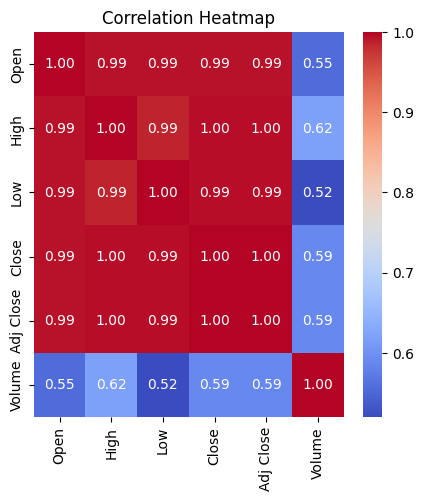

In [ ]:
# Correlation heatmap
plt.figure(figsize=(5, 5))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
#Converting the string date & time in proper date & time format with the help of pandas. After that check is there any null value is present or not.
data['Date'] = pd.to_datetime(data['Date'],infer_datetime_format=True)
data.set_index('Date', inplace=True)
data.isnull().any()

<ipython-input-32-518d511f5666>:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data['Date'] = pd.to_datetime(data['Date'],infer_datetime_format=True)


,0
Open,True
High,True
Low,True
Close,True
Adj Close,True
Volume,True


In [ ]:
# Now, let’s check for the presence of null values in the dataset.
data.isnull().sum()

,0
Open,1
High,1
Low,1
Close,1
Adj Close,1
Volume,1


In [ ]:
#Dropping those missing values so that we do not have any errors while analyzing
data = data.dropna()
data

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-11-09,0.001207,0.001415,0.001181,0.001415,0.001415,6259550.0
2017-11-10,0.001421,0.001431,0.001125,0.001163,0.001163,4246520.0
2017-11-11,0.001146,0.001257,0.001141,0.001201,0.001201,2231080.0
2017-11-12,0.001189,0.001210,0.001002,0.001038,0.001038,3288960.0
2017-11-13,0.001046,0.001212,0.001019,0.001211,0.001211,2481270.0
...,...,...,...,...,...,...
2022-08-30,0.063899,0.064408,0.060550,0.061525,0.061525,328934727.0
2022-08-31,0.061534,0.063333,0.061058,0.061330,0.061330,309748693.0
2022-09-01,0.061336,0.062479,0.060194,0.062372,0.062372,328765413.0


In [ ]:
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1.760000e+03
mean,0.059575,0.063096,0.056126,0.059619,0.059619,1.016258e+09
std,0.101325,0.109152,0.093695,0.101379,0.101379,3.563999e+09
min,0.001046,0.001210,0.001002,0.001038,0.001038,1.431720e+06
25%,0.002550,0.002616,0.002500,0.002548,0.002548,2.307671e+07
50%,0.003476,0.003603,0.003356,0.003495,0.003495,8.981855e+07
75%,0.070633,0.075035,0.068478,0.070657,0.070657,6.565853e+08
max,0.687801,0.737567,0.608168,0.684777,0.684777,6.941068e+10


Text(0.5, 1.0, 'Date vs Close of 2021')

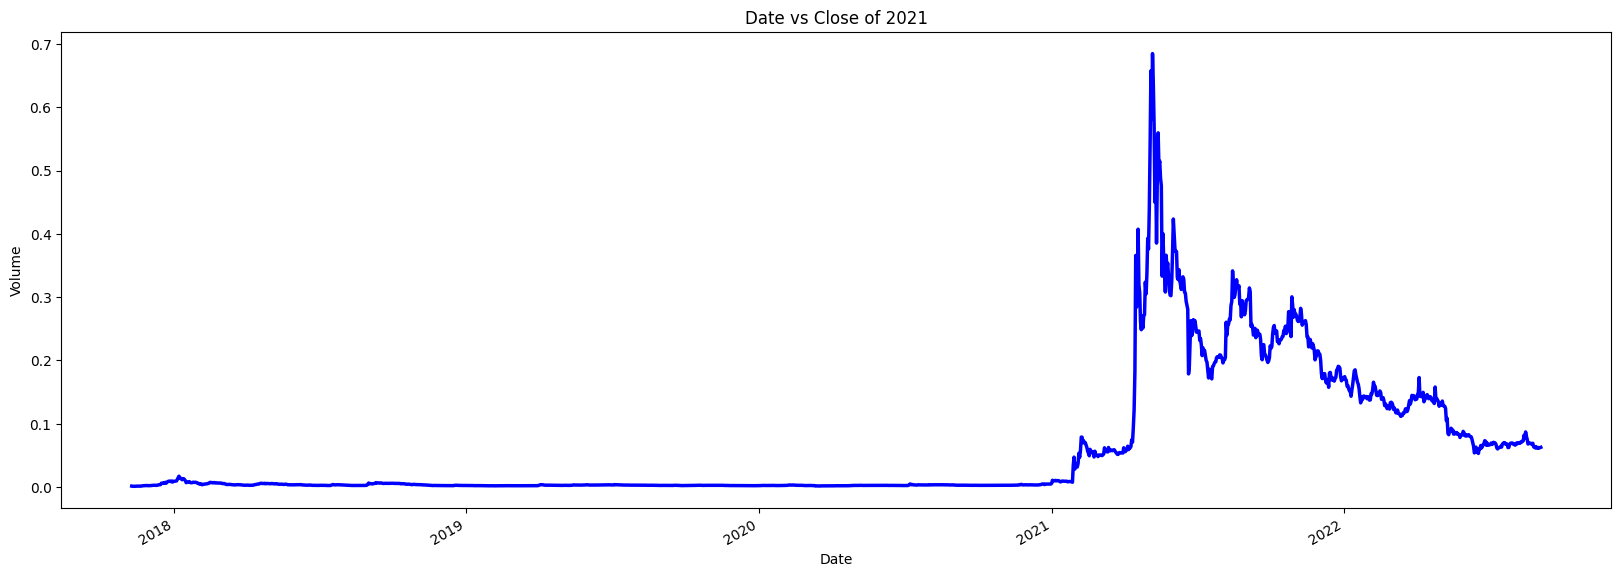

In [ ]:
#analyze the closing price as we need it to perform the prediction
plt.figure(figsize=(20, 7))
x = data.groupby('Date')['Close'].mean()
x.plot(linewidth=2.5, color='b')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title("Date vs Close of 2021")

<ipython-input-37-fe975df5456d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Rolling_Mean'] = data['Close'].rolling(window=30).mean()
<ipython-input-37-fe975df5456d>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Rolling_Std'] = data['Close'].rolling(window=30).std()


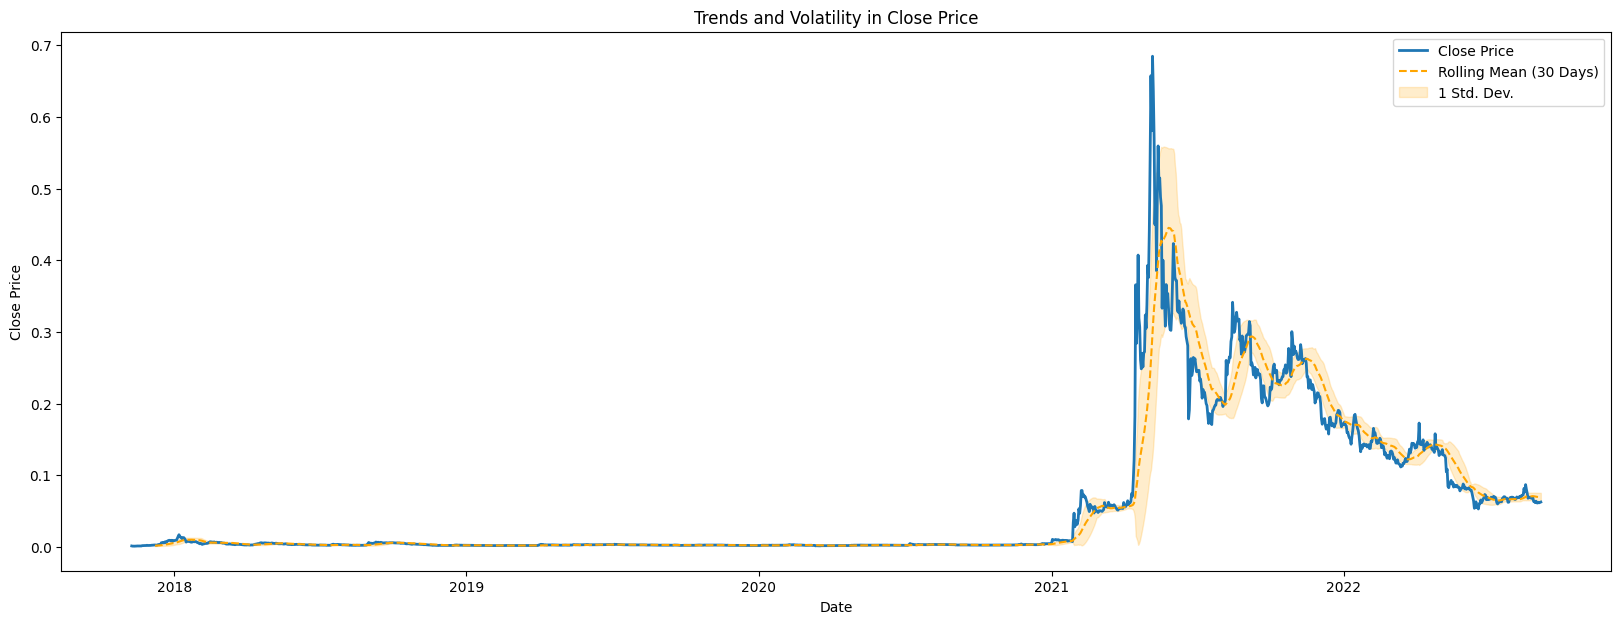

In [ ]:
# Plot a rolling mean and standard deviation for Close to observe trends
data['Rolling_Mean'] = data['Close'].rolling(window=30).mean()
data['Rolling_Std'] = data['Close'].rolling(window=30).std()

plt.figure(figsize=(20, 7))
plt.plot(data.index, data['Close'], label='Close Price', linewidth=2)
plt.plot(data.index, data['Rolling_Mean'], label='Rolling Mean (30 Days)', linestyle='--', color='orange')
plt.fill_between(data.index,
                 data['Rolling_Mean'] - data['Rolling_Std'],
                 data['Rolling_Mean'] + data['Rolling_Std'],
                 color='orange', alpha=0.2, label='1 Std. Dev.')
plt.title('Trends and Volatility in Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()


In [ ]:
data.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Rolling_Mean',
       'Rolling_Std'],
      dtype='object')

In [ ]:
data['Lag_1'] = data['Close'].shift(1)
data['Lag_2'] = data['Close'].shift(2)
data['Momentum'] = data['Close'] - data['Lag_1']
data['Rolling_Avg'] = data['Close'].rolling(window=7).mean()
data.dropna(inplace=True)

<ipython-input-39-4767d163fea0>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Lag_1'] = data['Close'].shift(1)
<ipython-input-39-4767d163fea0>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Lag_2'] = data['Close'].shift(2)
<ipython-input-39-4767d163fea0>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

In [ ]:
 # Train-Test Split for Time-Series
from sklearn.model_selection import train_test_split
X = data[['Lag_1', 'Lag_2', 'Momentum', 'Rolling_Avg']]
y = data['Close']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
# Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
# Make predictions
y_pred = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
# Evaluate the model
rf_mse = mean_squared_error(y_test, y_pred)
rf_r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 0.0011844107899815367
R^2 Score: 0.703481611028625


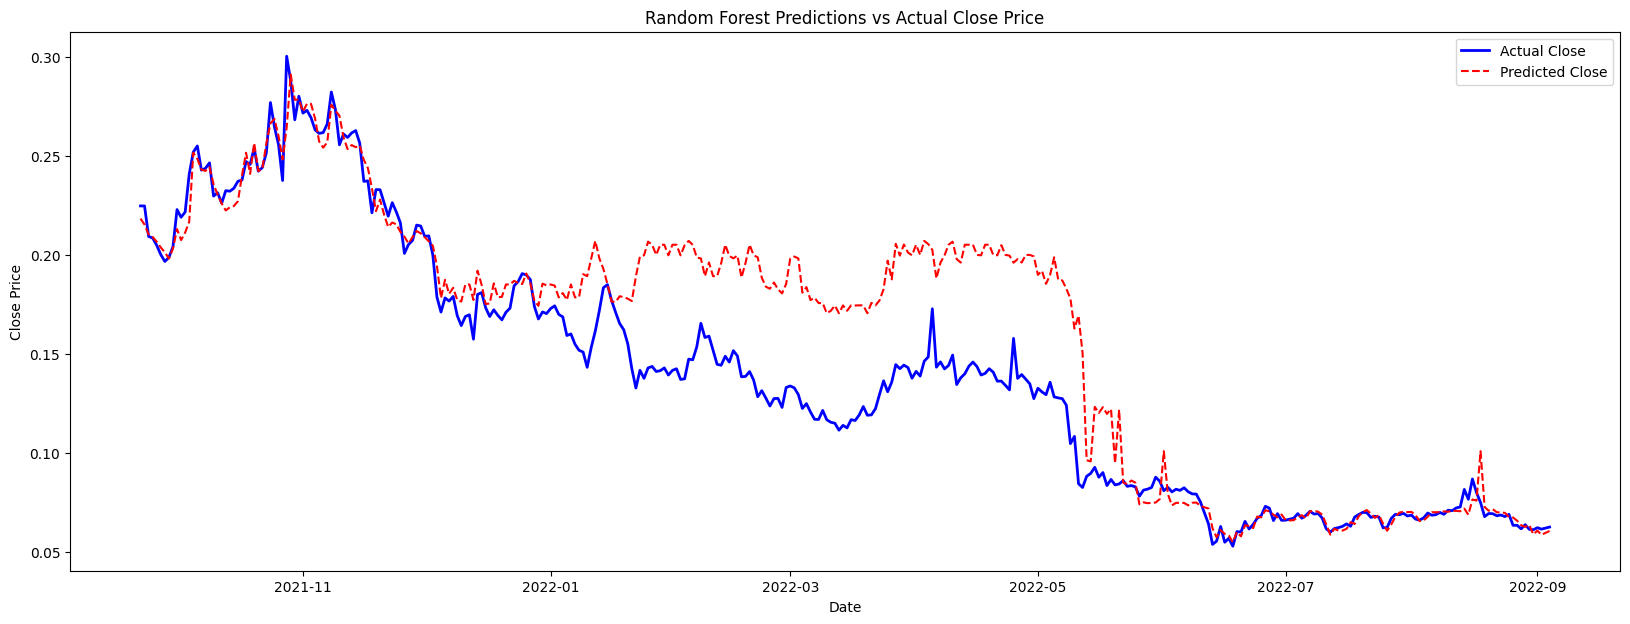

In [ ]:
# Plot Predictions vs Actual
plt.figure(figsize=(20, 7))
plt.plot(data.index[-len(y_test):], y_test, label='Actual Close', color='blue', linewidth=2)
plt.plot(data.index[-len(y_test):], y_pred, label='Predicted Close', color='red', linestyle='--')
plt.title('Random Forest Predictions vs Actual Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
# Define parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
# Grid Search with cross-validation
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best MSE Score:", -grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Best MSE Score: 0.010627156873885364


In [ ]:
# LinearRegression
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))
print("R^2 Score:", r2_score(y_test, y_pred_lr))

In [ ]:
# support vector regressor
from sklearn.svm import SVR
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train)
y_pred_svr = svr_model.predict(X_test)
svr_mse = mean_squared_error(y_test, y_pred_svr)
svr_r2 = r2_score(y_test, y_pred_svr)
print("SVR MSE:", mean_squared_error(y_test, y_pred_svr))
print("R^2 Score:", r2_score(y_test, y_pred_svr))

In [ ]:
# Random Forest
importances = rf_model.feature_importances_
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=X.columns, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
# Define parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
# Grid Search with cross-validation
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best MSE Score:", -grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Best MSE Score: 0.010627156873885364


In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# Prepare data for XGBoost
X_train_xgb = X_train
X_test_xgb = X_test

# Train XGBoost model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train_xgb, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_xgb)

# Evaluate XGBoost
xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print(f"XGBoost MSE: {xgb_mse}")
print(f"XGBoost R²: {xgb_r2}")


XGBoost MSE: 0.0009488827434474632
XGBoost R²: 0.7624462857061896


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Train KNN model
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test)

# Evaluate KNN
knn_mse = mean_squared_error(y_test, y_pred_knn)
knn_r2 = r2_score(y_test, y_pred_knn)

print(f"KNN MSE: {knn_mse}")
print(f"KNN R²: {knn_r2}")


KNN MSE: 0.0005499956500850718
KNN R²: 0.8623080560528904


In [ ]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'Linear Regression', 'Support Vector Regressor','xgboost','KNeighborsRegressor'],
    'MSE': [rf_mse,lr_mse,svr_mse,xgb_mse,knn_mse],
    'R² Score': [rf_r2, lr_r2, svr_r2,xgb_r2,knn_r2]
})

print(results)

                      Model           MSE  R² Score
0             Random Forest  1.184411e-03  0.703482
1         Linear Regression  1.666040e-33  1.000000
2  Support Vector Regressor  9.320994e-03 -1.333520
3                   xgboost  9.488827e-04  0.762446
4       KNeighborsRegressor  5.499957e-04  0.862308
